# Fit speedup dataframe for one `run_id`

Uses [`load_speedups_for_run`](plot_results.py) from `plot_results.py`: for each `(n_samples, n_features)`, speedups are `fit_time` at `max_num_threads == 1` divided by `fit_time` at each thread count.

The table columns are **`n_samples`**, **`n_features`**, **`n_threads`** (same values as CSV `max_num_threads`), and **`fit_speedup`**. A later cell reuses **`make_speedup_figure`** for the same 2×3 panel plot as `python plot_results.py <run_id>`.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from plot_results import get_all_run_ids, load_cpu_info, load_speedups_for_run, make_speedup_figure


def all_runs_meta_dataframe():
    """One row per run in `get_all_run_ids()` order: run_id, machine, processor, n_cpu (logical cores)."""
    rows = []
    for run_id in get_all_run_ids():
        cpu = load_cpu_info(run_id)
        rows.append(
            {
                "run_id": run_id,
                "machine": cpu.get("machine"),
                "processor": cpu.get("processor"),
                "n_cpu": cpu.get("cpu_logical_cores"),
            }
        )
    return pd.DataFrame(rows)


meta = all_runs_meta_dataframe()
display(meta)

,run_id,machine,processor,n_cpu
0,20260319_170137,arm64,arm,8
1,20260311_092054,aarch64,aarch64,4
2,20260311_092220,aarch64,aarch64,8
3,20260311_092340,aarch64,aarch64,16
4,20260311_092453,aarch64,aarch64,32
5,20260311_092621,x86_64,x86_64,4
6,20260311_092729,x86_64,x86_64,8
7,20260311_092853,x86_64,x86_64,16
8,20260311_092947,x86_64,x86_64,32


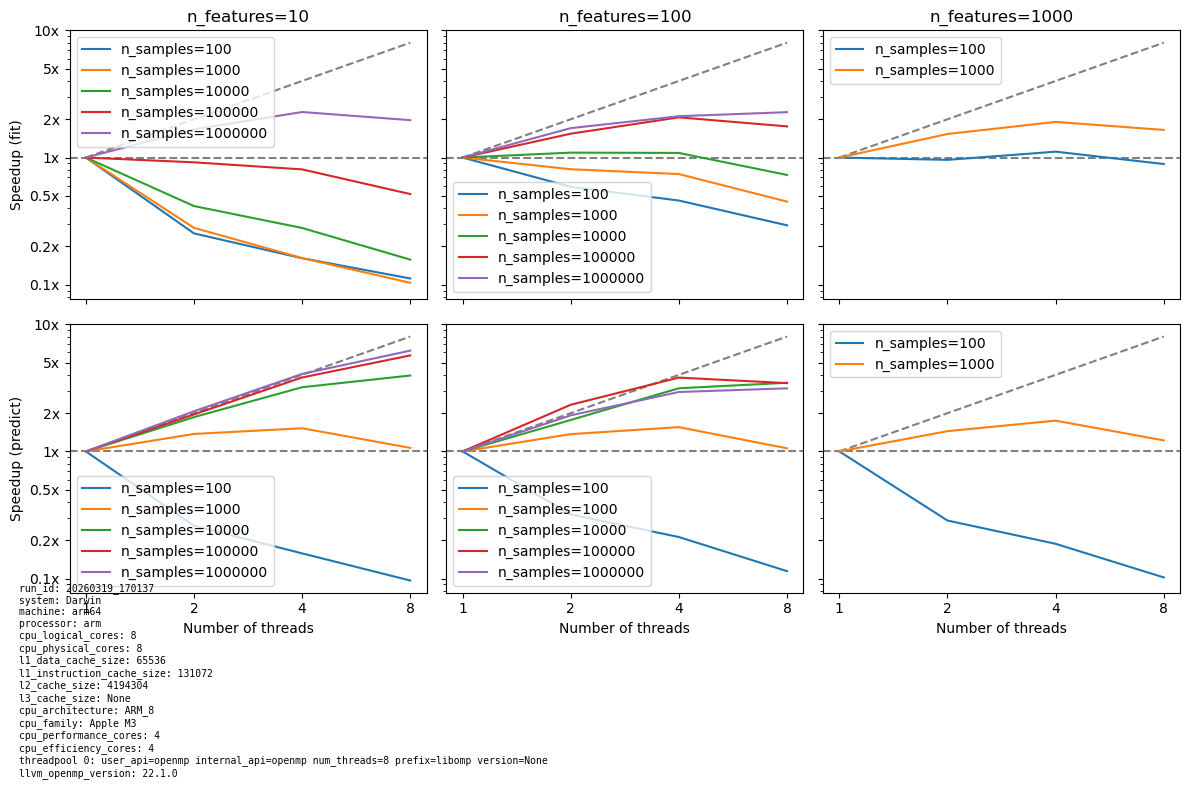

,run_id,machine,processor,n_cpu
0,20260319_170137,arm64,arm,8


,n_samples,n_features,n_threads,fit_speedup
0,100,10,1,1.000000
1,100,10,2,0.253505
2,100,10,4,0.161689
3,100,10,8,0.112090
4,100,100,1,1.000000


In [2]:
RUN_ID = "20260319_170137"  # results/bench_num_threads.{RUN_ID}.csv

# Same panels as: python plot_results.py RUN_ID
fig = make_speedup_figure(RUN_ID)
plt.show()


def fit_speedup_dataframe(run_id):
    """Rows from one benchmark run: shape, thread count, and fit_speedup."""
    raw = load_speedups_for_run(run_id)
    out = raw[["n_samples", "n_features", "max_num_threads", "fit_speedup"]].copy()
    return out.rename(columns={"max_num_threads": "n_threads"})


df = fit_speedup_dataframe(RUN_ID)
display(meta.query(f"run_id=='{RUN_ID}'"))
display(df.head())

### Linear model (full data)

$$
\log(\mathrm{fit\_speedup}) = \bigl(a\log(n_{\mathrm{samples}}) + b\log(n_{\mathrm{features}}) + c\bigr)\,\log(n_{\mathrm{threads}})
$$

Equivalently $\log y = a\,Ls\,Lt + b\,Lf\,Lt + c\,Lt$ with $Ls=\log(n_{\mathrm{samples}})$ etc. Fit `LinearRegression(fit_intercept=False)` on all rows (OLS, no holdout).

In [5]:
import numpy as np
from matplotlib.ticker import NullLocator
from sklearn.linear_model import LinearRegression


def fit_loglinear_model(df):
    """Fit log(fit_speedup) = a*Ls*Lt + b*Lf*Lt + c*Lt (natural logs). Returns fitted LinearRegression (coef_ = a, b, c)."""
    Ls = np.log(df["n_samples"].to_numpy(dtype=float))
    Lf = np.log(df["n_features"].to_numpy(dtype=float))
    Lt = np.log(df["n_threads"].to_numpy(dtype=float))
    y = np.log(df["fit_speedup"].to_numpy(dtype=float))
    X = np.column_stack([Ls * Lt, Lf * Lt, Lt])
    reg = LinearRegression(fit_intercept=False)
    reg.fit(X, y)
    return reg


def pred_fit_speedup_from_reg(reg, n_samples, n_features, n_threads_arr):
    """log(y) = (a*Ls + b*Lf + c) * Lt using reg.coef_."""
    a, b, c = reg.coef_
    Ls = np.log(float(n_samples))
    Lf = np.log(float(n_features))
    Lt = np.log(np.asarray(n_threads_arr, dtype=float))
    return np.exp((a * Ls + b * Lf + c) * Lt)


def plot_fit_speedup_model_vs_observed(run_id):
    """Observed (o) vs log-linear model (line) for one benchmark run."""
    df = fit_speedup_dataframe(run_id)
    reg = fit_loglinear_model(df)

    thread_vals = sorted(df["n_threads"].unique())
    t_fine = np.geomspace(float(thread_vals[0]), float(thread_vals[-1]), 80)
    ns_list = sorted(df["n_samples"].unique())
    nf_list = sorted(df["n_features"].unique())
    cmap = plt.colormaps["tab10"]
    ns_color = {ns: cmap(i % 10) for i, ns in enumerate(ns_list)}

    fig, axs = plt.subplots(1, len(nf_list), figsize=(3.8 * len(nf_list), 3.4), sharey=True, squeeze=False)
    for j, nf in enumerate(nf_list):
        ax = axs[0, j]
        sub = df[df["n_features"] == nf]
        for ns in ns_list:
            g = sub[sub["n_samples"] == ns].sort_values("n_threads")
            if g.empty:
                continue
            color = ns_color[ns]
            ax.plot(g["n_threads"], g["fit_speedup"], "o-", alpha=0.5, color=color, ms=5, label=f"{ns:,} samples")
            ax.plot(
                t_fine,
                pred_fit_speedup_from_reg(reg, ns, nf, t_fine),
                "--",
                alpha=0.5,
                color=color,
                lw=1.5,
            )
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_xticks(thread_vals)
        ax.set_xticklabels(thread_vals)
        ax.xaxis.set_minor_locator(NullLocator())
        ax.set_xlabel("n_threads")
        ax.set_title(f"n_features = {nf:,}")
        if j == 0:
            ax.set_ylabel("fit_speedup")
        if j == 1:
            ax.legend(title="n_samples", fontsize=7, title_fontsize=8)
        ax.axhline(1.0, color="gray", ls=":", lw=0.8, zorder=0)
        ax.plot(thread_vals, thread_vals, "--", color="gray", lw=0.8, zorder=0)

    fig.suptitle(f"fit_speedup vs n_threads (run {run_id}) — o=data, line=model", y=1.02)
    fig.tight_layout()
    return fig


a = 0.149958
b = 0.278514
c = -2.66705


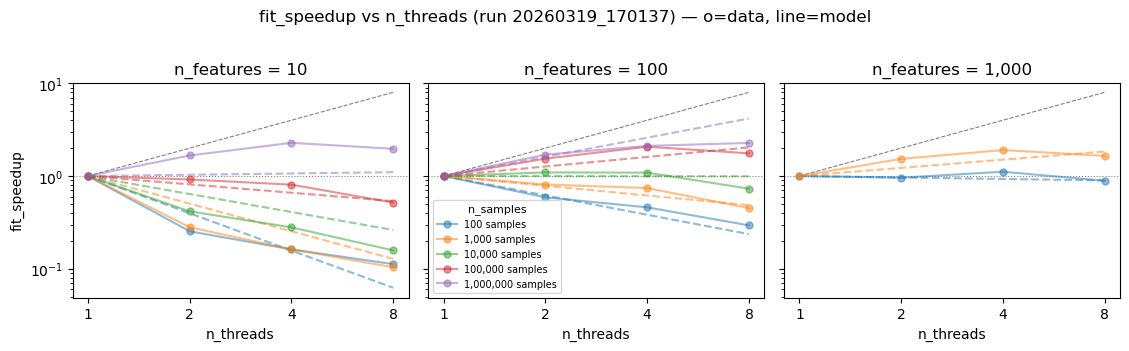

In [6]:
reg = fit_loglinear_model(df)
a, b, c = reg.coef_
print(f"a = {a:.6g}\nb = {b:.6g}\nc = {c:.6g}")

fig = plot_fit_speedup_model_vs_observed(RUN_ID)
plt.show()
